In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/deepfake-thesis/src

/content/drive/MyDrive/deepfake-thesis/src


In [3]:
!ls

create_splits.py	models.py		       train_efficientnet.ipynb
crop_faces.py		__pycache__		       train_efficientnet.py
dataloaders.py		robustness_dataset.py	       train_xception.ipynb
dataset.py		robustness_transforms.py       train_xception.py
evaluate_robustness.py	robustness_transform_test.png
extract_frames.py	test_robustness_transforms.py


In [4]:
!ls -lh /content/drive/MyDrive/deepfake-thesis/metadata

total 21M
-rw------- 1 root root 7.6M Aug 19 10:50 dataset_splits.csv
-rw------- 1 root root 7.1M Aug 19 10:20 faces_metadata.csv
-rw------- 1 root root 6.4M Aug 18 16:11 frames_metadata.csv
drwx------ 2 root root 4.0K Sep 12 15:29 official_splits


In [5]:
!mkdir -p /content/deepfake-thesis/faces

!unzip -q \
"/content/drive/MyDrive/deepfake-thesis/faces.zip" \
-d "/content/deepfake-thesis/"

In [6]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


/content/drive/MyDrive/deepfake-thesis/src
Immagine selezionata:
Filename: original_000_frame_00.png
Label: 0
Manipulation: original
Dimensione originale: (149, 194)
original     -> dimensione finale: (149, 194)
jpeg_q90     -> dimensione finale: (149, 194)
jpeg_q70     -> dimensione finale: (149, 194)
jpeg_q50     -> dimensione finale: (149, 194)
resize_75    -> dimensione finale: (149, 194)
resize_50    -> dimensione finale: (149, 194)
resize_25    -> dimensione finale: (149, 194)
blur_05      -> dimensione finale: (149, 194)
blur_10      -> dimensione finale: (149, 194)
blur_20      -> dimensione finale: (149, 194)


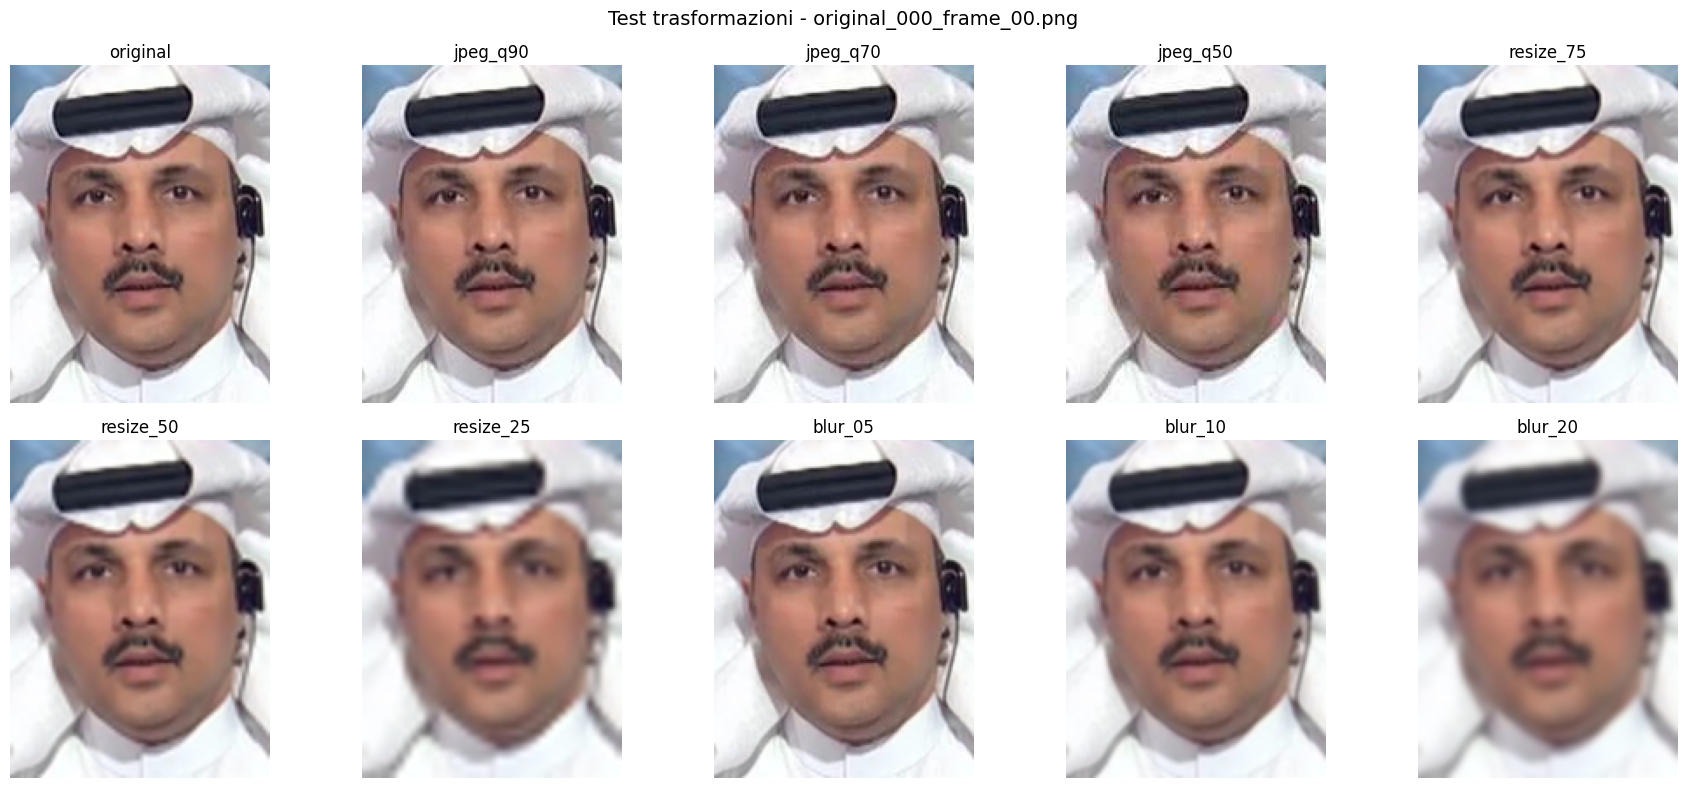


Figura salvata in: /content/drive/MyDrive/deepfake-thesis/src/robustness_transform_test.png


<Figure size 640x480 with 0 Axes>

In [7]:
%cd /content/drive/MyDrive/deepfake-thesis/src
%run test_robustness_transforms.py

In [8]:
%cd /content/drive/MyDrive/deepfake-thesis/src
%run evaluate_robustness.py

/content/drive/MyDrive/deepfake-thesis/src
ROBUSTNESS EVALUATION

Device: cuda
GPU: Tesla T4

File necessari trovati correttamente.

SMOKE TEST

Verranno elaborati soltanto 2 batch.

CARICAMENTO MODELLO: XCEPTION
Checkpoint epoca: 2
Validation loss: 0.1404741169435461

----------------------------------------------------------------------
XCEPTION | condizione: jpeg_q90
----------------------------------------------------------------------
Campioni test: 6894


xception jpeg_q90:   0%|          | 0/216 [00:00<?, ?it/s]


Risultati:
Loss:      0.5091
Accuracy:  0.8438
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
ROC-AUC:   nan
TN=54 | FP=10 | FN=0 | TP=0

SMOKE TEST COMPLETATO CORRETTAMENTE

Nessun risultato dello smoke test è stato salvato.


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [9]:
!grep "SMOKE_TEST =" evaluate_robustness.py

# SMOKE_TEST = False
SMOKE_TEST = True


In [11]:
!sed -i 's/SMOKE_TEST = True/SMOKE_TEST = False/' /content/drive/MyDrive/deepfake-thesis/src/evaluate_robustness.py

In [12]:
!grep "SMOKE_TEST =" /content/drive/MyDrive/deepfake-thesis/src/evaluate_robustness.py

# SMOKE_TEST = False
SMOKE_TEST = False


In [13]:
%cd /content/drive/MyDrive/deepfake-thesis/src
%run evaluate_robustness.py

/content/drive/MyDrive/deepfake-thesis/src
ROBUSTNESS EVALUATION

Device: cuda
GPU: Tesla T4

File necessari trovati correttamente.

CARICAMENTO MODELLO: XCEPTION
Checkpoint epoca: 2
Validation loss: 0.1404741169435461

----------------------------------------------------------------------
XCEPTION | condizione: jpeg_q90
----------------------------------------------------------------------
Campioni test: 6894


xception jpeg_q90:   0%|          | 0/216 [00:00<?, ?it/s]


Risultati:
Loss:      0.1927
Accuracy:  0.9294
Precision: 0.9591
Recall:    0.9523
F1:        0.9557
ROC-AUC:   0.9728
TN=1160 | FP=224 | FN=263 | TP=5247

Predizioni salvate in:
/content/drive/MyDrive/deepfake-thesis/results/robustness/xception_jpeg_q90_predictions.csv

Summary aggiornato:
/content/drive/MyDrive/deepfake-thesis/results/robustness/robustness_summary.csv

----------------------------------------------------------------------
XCEPTION | condizione: jpeg_q70
----------------------------------------------------------------------
Campioni test: 6894


xception jpeg_q70:   0%|          | 0/216 [00:00<?, ?it/s]


Risultati:
Loss:      0.8149
Accuracy:  0.7216
Precision: 0.9771
Recall:    0.6673
F1:        0.7931
ROC-AUC:   0.9053
TN=1298 | FP=86 | FN=1833 | TP=3677

Predizioni salvate in:
/content/drive/MyDrive/deepfake-thesis/results/robustness/xception_jpeg_q70_predictions.csv

Summary aggiornato:
/content/drive/MyDrive/deepfake-thesis/results/robustness/robustness_summary.csv

----------------------------------------------------------------------
XCEPTION | condizione: jpeg_q50
----------------------------------------------------------------------
Campioni test: 6894


...


Risultati:
Loss:      0.2883
Accuracy:  0.8841
Precision: 0.9731
Recall:    0.8793
F1:        0.9238
ROC-AUC:   0.9606
TN=1250 | FP=134 | FN=665 | TP=4845

Predizioni salvate in:
/content/drive/MyDrive/deepfake-thesis/results/robustness/efficientnet_b4_blur_05_predictions.csv

Summary aggiornato:
/content/drive/MyDrive/deepfake-thesis/results/robustness/robustness_summary.csv

----------------------------------------------------------------------
EFFICIENTNET_B4 | condizione: blur_10
----------------------------------------------------------------------
Campioni test: 6894


efficientnet_b4 blur_10:   0%|          | 0/216 [00:00<?, ?it/s]


Risultati:
Loss:      0.6646
Accuracy:  0.8377
Precision: 0.8359
Recall:    0.9917
F1:        0.9071
ROC-AUC:   0.8255
TN=311 | FP=1073 | FN=46 | TP=5464

Predizioni salvate in:
/content/drive/MyDrive/deepfake-thesis/results/robustness/efficientnet_b4_blur_10_predictions.csv

Summary aggiornato:
/content/drive/MyDrive/deepfake-thesis/results/robustness/robustness_summary.csv

----------------------------------------------------------------------
EFFICIENTNET_B4 | condizione: blur_20
----------------------------------------------------------------------
Campioni test: 6894


efficientnet_b4 blur_20:   0%|          | 0/216 [00:00<?, ?it/s]


Risultati:
Loss:      0.7670
Accuracy:  0.8045
Precision: 0.8057
Recall:    0.9955
F1:        0.8906
ROC-AUC:   0.6355
TN=61 | FP=1323 | FN=25 | TP=5485

Predizioni salvate in:
/content/drive/MyDrive/deepfake-thesis/results/robustness/efficientnet_b4_blur_20_predictions.csv

Summary aggiornato:
/content/drive/MyDrive/deepfake-thesis/results/robustness/robustness_summary.csv

VALUTAZIONE ROBUSTEZZA COMPLETATA

Risultati disponibili in:
/content/drive/MyDrive/deepfake-thesis/results/robustness


In [14]:
%cd /content/drive/MyDrive/deepfake-thesis/src
%run plot_robustness_confusion_matrices.py

/content/drive/MyDrive/deepfake-thesis/src

Xception

Xception - Original
TN=1256 | FP=128 | FN=249 | TP=5261
Salvata in: /content/drive/MyDrive/deepfake-thesis/results/robustness/confusion_matrices/xception_original_confusion_matrix.png

Xception - JPEG quality 90
TN=1160 | FP=224 | FN=263 | TP=5247
Salvata in: /content/drive/MyDrive/deepfake-thesis/results/robustness/confusion_matrices/xception_jpeg_q90_confusion_matrix.png

Xception - JPEG quality 70
TN=1298 | FP=86 | FN=1833 | TP=3677
Salvata in: /content/drive/MyDrive/deepfake-thesis/results/robustness/confusion_matrices/xception_jpeg_q70_confusion_matrix.png

Xception - JPEG quality 50
TN=1364 | FP=20 | FN=3857 | TP=1653
Salvata in: /content/drive/MyDrive/deepfake-thesis/results/robustness/confusion_matrices/xception_jpeg_q50_confusion_matrix.png

Xception - Resize 75%
TN=1014 | FP=370 | FN=303 | TP=5207
Salvata in: /content/drive/MyDrive/deepfake-thesis/results/robustness/confusion_matrices/xception_resize_75_confusion_matrix.pn

<Figure size 640x480 with 0 Axes>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/deepfake-thesis/src
%run analyze_prediction_stability.py

/content/drive/MyDrive/deepfake-thesis/src
ANALISI DELLA STABILITÀ DELLE PREDIZIONI

MODELLO: XCEPTION

----------------------------------------------------------------------
XCEPTION | jpeg_q90
----------------------------------------------------------------------
Campioni: 6894
Prediction flip: 286 (4.15%)
REAL -> FAKE: 184 (2.67%)
FAKE -> REAL: 102 (1.48%)
Mean |Δ P(fake)|: 0.0469
Mean Δ P(fake): +0.0118
Dettaglio salvato in: /content/drive/MyDrive/deepfake-thesis/results/robustness/stability/xception_jpeg_q90_stability.csv

----------------------------------------------------------------------
XCEPTION | jpeg_q70
----------------------------------------------------------------------
Campioni: 6894
Prediction flip: 1776 (25.76%)
REAL -> FAKE: 75 (1.09%)
FAKE -> REAL: 1701 (24.67%)
Mean |Δ P(fake)|: 0.2555
Mean Δ P(fake): -0.2337
Dettaglio salvato in: /content/drive/MyDrive/deepfake-thesis/results/robustness/stability/xception_jpeg_q70_stability.csv

---------------------------------

In [5]:
from pathlib import Path
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/deepfake-thesis")

metadata_file = PROJECT / "metadata" / "dataset_splits.csv"
robustness_dir = PROJECT / "results" / "robustness"

metadata = pd.read_csv(metadata_file)

print("Colonne metadata:")
print(metadata.columns.tolist())

# stesso ordine del test set utilizzato dai Dataset
test_metadata = (
    metadata[
        metadata["split"].astype(str).str.lower() == "test"
    ]
    .reset_index(drop=True)
)

print("\nCampioni test:", len(test_metadata))

assert len(test_metadata) == 6894

conditions = [
    "jpeg_q90",
    "jpeg_q70",
    "jpeg_q50",
    "resize_75",
    "resize_50",
    "resize_25",
    "blur_05",
    "blur_10",
    "blur_20",
]

models = [
    "xception",
    "efficientnet_b4",
]

for model in models:
    for condition in conditions:

        file = (
            robustness_dir
            / f"{model}_{condition}_predictions.csv"
        )

        df = pd.read_csv(file)

        assert len(df) == 6894

        if "filename" not in df.columns:
            raise ValueError(
                f"filename non presente in {file.name}"
            )

        same_filenames = (
            df["filename"]
            .astype(str)
            .reset_index(drop=True)
            .equals(
                test_metadata["filename"]
                .astype(str)
                .reset_index(drop=True)
            )
        )

        if not same_filenames:
            raise ValueError(
                f"ORDINE NON COINCIDENTE: "
                f"{model} - {condition}"
            )

        print(
            f"OK: {model} - {condition}"
        )

print("\nTUTTI I FILE DEGRADATI SEGUONO LO STESSO ORDINE DEL TEST SET.")

Colonne metadata:
['filename', 'frame_path', 'label', 'manipulation', 'source_video', 'frame_index', 'sample_number', 'timestamp_seconds', 'total_video_frames', 'fps', 'face_detected', 'detection_score', 'split']

Campioni test: 6894
OK: xception - jpeg_q90
OK: xception - jpeg_q70
OK: xception - jpeg_q50
OK: xception - resize_75
OK: xception - resize_50
OK: xception - resize_25
OK: xception - blur_05
OK: xception - blur_10
OK: xception - blur_20
OK: efficientnet_b4 - jpeg_q90
OK: efficientnet_b4 - jpeg_q70
OK: efficientnet_b4 - jpeg_q50
OK: efficientnet_b4 - resize_75
OK: efficientnet_b4 - resize_50
OK: efficientnet_b4 - resize_25
OK: efficientnet_b4 - blur_05
OK: efficientnet_b4 - blur_10
OK: efficientnet_b4 - blur_20

TUTTI I FILE DEGRADATI SEGUONO LO STESSO ORDINE DEL TEST SET.
